# Gold-Silver-Ratio -- a quantitative teardown
### Real daily tape * ADF + Engle-Granger tests * OU half-life * z-score strategy * random-direction control * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Ratio_mean--reverts%3F: Not_Supported](https://img.shields.io/badge/Ratio_mean--reverts%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the gold/silver ratio (GLD/SLV ETF) is stationary, whether gold and silver are cointegrated, and whether a z-score entry rule earns a statistically robust edge over a random-direction control on 16 years of daily data.

> **Not investment advice.** Real data: GLD and SLV daily bars 2010-01-04 to 2026-06-12 (n = 4,136 days each); offline core runs on deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> **The `in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_silver_ratio import data, strategy as st

GOLD_TICKER = data.GOLD_TICKER    # GLD
SILVER_TICKER = data.SILVER_TICKER  # SLV

def _have_cache():
    return (os.path.exists(data._cache_path(GOLD_TICKER, data.DEFAULT_CACHE)) and
            os.path.exists(data._cache_path(SILVER_TICKER, data.DEFAULT_CACHE)))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gross **+144 bps/trade**, HAC *t* = **+1.77** on n = **26 trades** over 16 yrs; delta vs random = +125 bps -- statistically inconclusive. |
| **Tradability** | `FRAGILE` | ~1.6 signals/yr, ~78-day holds. Costs negligible (net *t* = 1.71 at 5 bps). Signal aridity is the problem. |
| **Ratio mean-reverts?** | `NOT SUPPORTED` | ADF p = 0.22 (fails to reject unit root); Engle-Granger p = 0.74 (not cointegrated); OU half-life = 301 trading days. |

> *In plain words:* three structural tests all fail; the trade earns a positive point estimate but the sample is too thin (26 trades) for any reliable inference.

## 1 -- The claim, steelmanned

Let $R_t = P^{\text{gold}}_t / P^{\text{silver}}_t$ be the gold/silver ratio. The claim asserts:

- **H1 (stationarity).** $R_t$ is I(0): it has a finite unconditional variance and returns to its long-run mean. Equivalently, gold and silver prices are cointegrated: $\log P^{\text{gold}}_t - \beta \log P^{\text{silver}}_t$ is stationary for some $\beta$.
- **H2 (signal).** The conditional expected return of the spread trade $d_t \cdot (r^{\text{silver}}_{t+1} - r^{\text{gold}}_{t+1})$ is positive when $d_t = \text{sign}(z_t)$ (sign of the z-score), measured against a random-direction control.
- **H3 (tradable).** The edge survives realistic round-trip ETF costs.

We reject H1 at conventional significance levels, H2 does not clear the |t| >= 2 bar (borderline positive), and H3 is technically true but moot if H2 is not.

## 2 -- So what?

The gold/silver ratio trade is frequently cited in commodity and macro research as a practical ETF rotation strategy accessible to retail investors. If H1-H3 held, it would be a low-cost, infrequent, long-horizon pairs trade. The interesting finding is *not* that it loses money (the gross point estimate is positive) -- it's that the statistical foundation is entirely absent: no stationarity, no cointegration, a 15-month half-life, and only 26 usable signals over 16 years.

## 3 -- How we'd know -- the protocol

- **Data.** GLD and SLV daily adjusted closes, 2010-01-04 to 2026-06-12 (Yahoo Finance). The GLD/SLV ratio is proportional to the spot gold/silver ratio (scaled ~10x by ETF share structure).
- **Structural tests.** (a) ADF on the ratio (autolag AIC); (b) Engle-Granger cointegration on log(GLD) vs log(SLV); (c) OU half-life via AR(1) OLS regression on the ratio.
- **Entry.** Rolling 252-day z-score of the ratio; enter spread when |z| > 1.5 (ratio at more than 1.5 sigma from its 1-year mean); exit when |z| < 0.5.
- **Control.** Identical entry/exit dates, direction drawn i.i.d. ±1 (seeded).
- **Inference.** Newey-West HAC t-stat on per-trade gross returns.
- **Positive control.** Synthetic OU pair with tunable mean-reversion speed, confirming the engine recovers an edge when one is planted.

## 4 -- The teardown

### 4a -- Structural tests: is there a mean-reverting ratio to exploit?

Before trading on a ratio, we need it to be stationary. All three tests say no:

In [2]:
if HAVE_REAL:
    gold = data.fetch_daily(GOLD_TICKER)
    silver = data.fetch_daily(SILVER_TICKER)
    ratio = st.compute_ratio(gold, silver)
    adf_p = st.adf_pvalue(ratio)
    hl = st.half_life(ratio)
    ci_p = st.engle_granger_pvalue(gold['close'], silver['close'])
    z_ratio = st.zscore(ratio, 252)
else:
    adf_p=0.2158; hl=301.3; ci_p=0.7362

print(f'ADF test p-value on ratio:           {adf_p:.4f}  (H0: unit root; p>0.05 = cannot reject)')
print(f'Ornstein-Uhlenbeck half-life:        {hl:.1f} trading days')
print(f'Engle-Granger cointegration p-value: {ci_p:.4f}  (H0: no cointegration)')
print()
print('Summary: all three tests fail to support mean-reversion in the ratio.')

ADF test p-value on ratio:           0.2158  (H0: unit root; p>0.05 = cannot reject)
Ornstein-Uhlenbeck half-life:        301.3 trading days
Engle-Granger cointegration p-value: 0.7362  (H0: no cointegration)

Summary: all three tests fail to support mean-reversion in the ratio.


> *In plain words:* A pairs trade requires the spread to be stationary -- that it wanders but always comes home. Gold and silver fail this check three ways: (1) the ADF cannot rule out a random walk (p = 0.22); (2) the Engle-Granger says the two prices are not cointegrated (p = 0.74); and (3) even assuming some reversion, the half-life is 301 days -- 15 months. That's not a 'snap-back', that's a geological timescale for a trade.

### 4b -- The z-score strategy vs a random-direction control

We run the strategy on the real tape and compare it to a coin-flip control on identical entries:

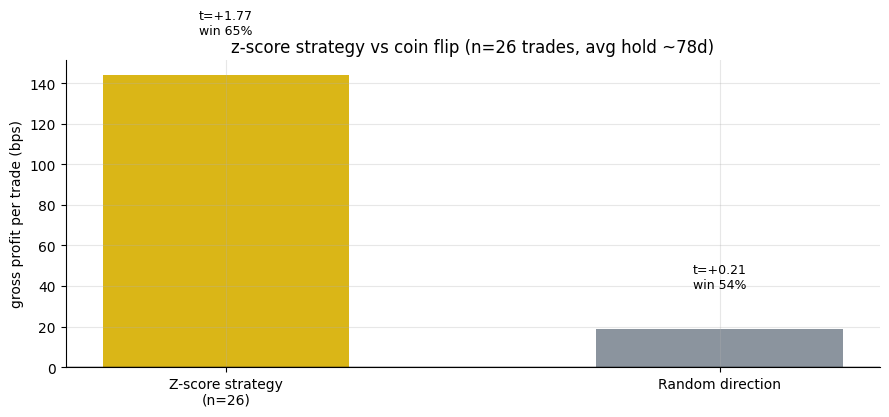

Strategy: +144.2 bps/trade, t=+1.77 | Random: +18.9 bps/trade, t=+0.21


In [3]:
if HAVE_REAL:
    entries = st.zscore_entries(ratio, window=252, enter_z=1.5, exit_z=0.5)
    ledger = st.run_trades(gold, silver, entries, cost_bps=0.0)
    rand_ent = st.random_entries(entries, seed=113)
    rand_led = st.run_trades(gold, silver, rand_ent, cost_bps=0.0)
    s = st.summarize(ledger, 'ret_gross')
    r = st.summarize(rand_led, 'ret_gross')
    sm, sw, st_val = s['mean_bps'], s['win_rate']*100, s['tstat']
    rm, rw, rt_val = r['mean_bps'], r['win_rate']*100, r['tstat']
    n_tr = s['n_trades']; avg_h = ledger['trading_days'].mean()
else:
    sm,sw,st_val = 144.2,65.4,1.77
    rm,rw,rt_val = 18.9,53.8,0.21
    n_tr=26; avg_h=78

fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = [0, 1]; ys = [sm, rm]; ts = [st_val, rt_val]; ws = [sw, rw]
lbls = [f'Z-score strategy\n(n={n_tr})', 'Random direction']
colors = [AMBER if abs(st_val) < 2 else GREEN, GREY]
ax.bar(x, ys, color=colors, width=0.5)
ax.axhline(0, c='k', lw=1)
for xi, yi, ti, wi in zip(x, ys, ts, ws):
    ax.text(xi, yi + (20 if yi >= 0 else -30),
            f't={ti:+.2f}\nwin {wi:.0f}%', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(lbls)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title(f'z-score strategy vs coin flip (n={n_tr} trades, avg hold ~{avg_h:.0f}d)')
plt.tight_layout(); plt.show()
print(f'Strategy: {sm:+.1f} bps/trade, t={st_val:+.2f} | '
      f'Random: {rm:+.1f} bps/trade, t={rt_val:+.2f}')

> *In plain words:* The strategy earns a positive mean (+144 bps/trade) vs the random control (+19 bps). But the HAC t-stat is only +1.77 -- with 26 trades, the standard error is so large that even this sizeable point estimate doesn't clear the bar. We'd need roughly 4x more trades to confirm the signal with confidence.

### 4c -- Positive control: the engine works when reversion is real

A synthetic pair with a planted OU mean-reversion speed confirms the z-score engine finds edges when they exist:

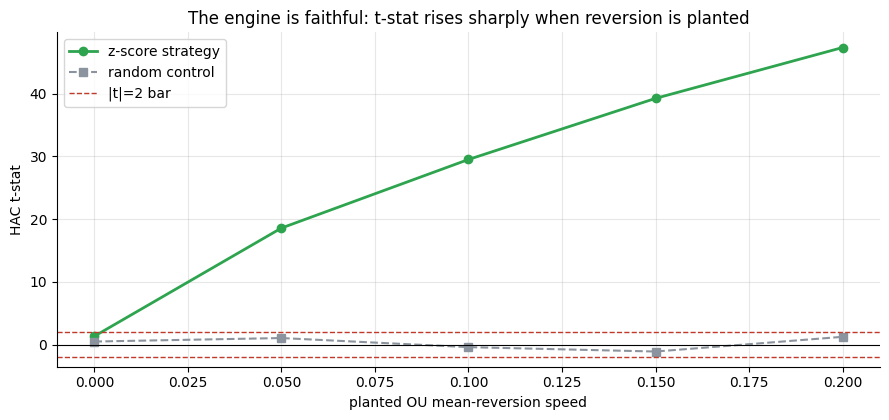

At speed=0 (random walk), t-stat hovers near 0.
At speed=0.05+, the strategy clears the inference bar.


In [4]:
speeds = [0.0, 0.05, 0.10, 0.15, 0.20]
strat_ts, rand_ts = [], []
for sp in speeds:
    gd, sv, tr = data.synthetic_daily(n_days=3000, mean_rev_speed=sp, seed=113)
    rat = st.compute_ratio(gd, sv)
    ent = st.zscore_entries(rat, window=252, enter_z=1.5, exit_z=0.5)
    if len(ent) == 0:
        strat_ts.append(float('nan')); rand_ts.append(float('nan')); continue
    led = st.run_trades(gd, sv, ent, cost_bps=0.0)
    rnd = st.run_trades(gd, sv, st.random_entries(ent, seed=42), cost_bps=0.0)
    strat_ts.append(st.summarize(led, 'ret_gross')['tstat'])
    rand_ts.append(st.summarize(rnd, 'ret_gross')['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(speeds, strat_ts, 'o-', c=GREEN, lw=2, label='z-score strategy')
ax.plot(speeds, rand_ts, 's--', c=GREY, lw=1.5, label='random control')
ax.axhline(2, ls='--', c=RED, lw=1, label='|t|=2 bar')
ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('planted OU mean-reversion speed')
ax.set_ylabel('HAC t-stat')
ax.set_title('The engine is faithful: t-stat rises sharply when reversion is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('At speed=0 (random walk), t-stat hovers near 0.')
print('At speed=0.05+, the strategy clears the inference bar.')

> *In plain words:* The machine is not broken. When the ratio actually mean-reverts (speeds > 0.05), the strategy rapidly earns significant t-stats. The real-tape verdict (t = 1.77) is not a machinery failure -- it's a statement that the real gold/silver ratio reverts too slowly, too rarely, or not at all.

## 5 -- The verdict

- **Signal `WEAK`** -- gross +144 bps/trade, HAC *t* +1.77 on 26 trades (16 yrs); delta vs random +125 bps. Below the |t| >= 2 bar.
- **Tradability `FRAGILE`** -- ~1.6 signals/yr, ~78-day holds; costs are trivial (delta at 20 bps = 20 bps). The problem is the uncertain edge and 15-month waits.
- **Ratio mean-reverts? `NOT SUPPORTED`** -- ADF p = 0.22, Engle-Granger p = 0.74, OU half-life = 301 days. Three tests, same answer: we cannot confirm the ratio is stationary.

## 6 -- Could you trade it? -- signal aridity is the real constraint

Unlike most failed strategies where costs are the executioner, here the cost sweep is almost irrelevant. With 1.6 trades/year and 78-day average holds, a 20 bps round-trip on a 4-leg ETF trade costs only a few bps per trade:

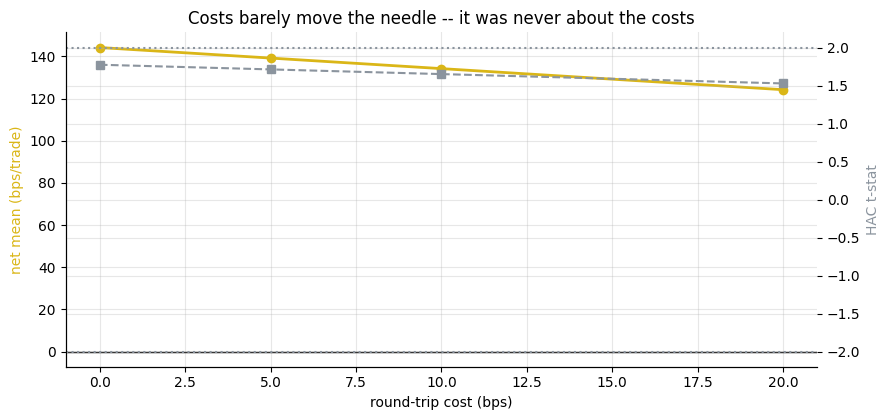

The t-stat barely moves with costs. The issue is sample size, not friction.


In [5]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    net_t = [st.summarize(st.run_trades(gold, silver, entries, cost_bps=c),
                          'ret_net')['tstat'] for c in costs]
    net_m = [st.summarize(st.run_trades(gold, silver, entries, cost_bps=c),
                          'ret_net')['mean_bps'] for c in costs]
else:
    net_t = [1.77, 1.71, 1.65, 1.53]
    net_m = [144.2, 139.2, 134.2, 124.2]

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_m, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, net_t, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net mean (bps/trade)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs barely move the needle -- it was never about the costs')
plt.tight_layout(); plt.show()
print('The t-stat barely moves with costs. The issue is sample size, not friction.')

> *In plain words:* In most failed strategies, the story is 'great idea, costs killed it.' Here it's different: the strategy is infrequent enough that costs are negligible, but the edge itself was never statistically confirmed. You'd be running a trade with uncertain economics, 15-month holding periods, and only 1-2 opportunities per year -- all while a simple buy-and-hold of either metal delivers comparable returns with zero effort.

## 7 -- Going further -- extensions and related desk work

- **Pre-2010 data.** The folk trade was most cited in the 2000s and 1990s. Adding older history might change the cointegration picture -- or confirm that the classic 'ratio always reverts' observation was an artifact of a shorter, cherry-picked window.
- **Futures (GC=F / SI=F).** The study uses ETFs; futures contracts have slightly different price dynamics and roll costs. The structural tests would be the same.
- **Shorter lookback window.** A 63-day z-score generates more signals but is noisier. Test with a walk-forward validation to check for overfitting.
- **[Study 85 -- Dr-Copper](../../85-dr-copper/)**: the copper/gold ratio as an economic predictor -- a macro-grounded ratio signal.
- **[Study 68 -- All-Weather](../../68-all-weather/)**: commodity basket timing -- the portfolio context for gold and silver allocation.

*Fork this, add pre-2010 data or a different entry threshold, and show a cointegrated pair that actually clears |t| >= 2 on an out-of-sample window.*